In [1]:
import numpy as np, pandas as pd
import sys
sys.path.insert(0, '/user/bnc2119/drd')
import torch
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib as mpl
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_wine, fetch_openml
import pandas as pd
from src.drd import DRD, AutoEncoder# stored in base
from matplotlib.ticker import ScalarFormatter
from utils import *
import pickle
%load_ext autoreload
%autoreload 2

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-15 10:33:59,312	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-09-15 10:33:59,603	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-09-15 10:34:03.785666: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757946843.797728    4600 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00

In [73]:
dataset, hidden_dim = 'diabetes', [442]
model_file = '/shared/share_mala/irchang/drd/models/db_t_pca_seed=0.pt'
teacher_file = '/shared/share_mala/irchang/drd/models/teacher/db_t_pca_seed=0.pkl'
lambda_exp_file = 'results/diabetes_pca_drd_joint_n=442.csv'

# dataset, hidden_dim = 'wine', [1000]
# model_file = '/shared/share_mala/irchang/drd/models/wi_t_pca_seed=0.pt'
# teacher_file = '/shared/share_mala/irchang/drd/models/teacher/wi_t_pca_seed=0.pkl'
# lambda_exp_file = 'results/wine_pca_drd_joint_n=178_v2.csv'

In [68]:
X_tr, X_te, y_tr, y_te = load_and_split(dataset, seed=0, labels=True)
ae_sc1_checkpoint = torch.load(model_file)
# ae_sc2_checkpoint = torch.load('/shared/share_mala/irchang/drd/models/sc_t_isomap_seed=0.pt')
ae_sc1 = AutoEncoder(input_dim=X_tr.shape[1], latent_dim=2, hidden_dims=hidden_dim)
ae_sc1.load_state_dict(ae_sc1_checkpoint)
# ae_sc2 = AutoEncoder(input_dim=X_tr.shape[1], latent_dim=2, hidden_dims=[8010])
# ae_sc2.load_state_dict(ae_sc2_checkpoint)

encoder layers: [Linear(in_features=10, out_features=442, bias=True), ReLU(), Linear(in_features=442, out_features=2, bias=True)]
decoder layers: [Linear(in_features=2, out_features=442, bias=True), ReLU(), Linear(in_features=442, out_features=10, bias=True)]


<All keys matched successfully>

In [69]:
student_sc1 = ae_sc1.encoder(torch.tensor(X_tr).float()).detach().numpy()
# student_sc2 = ae_sc2.encoder(torch.tensor(X_tr).float()).detach().numpy()
teacher_sc1 = pickle.load(open(teacher_file, 'rb')).transform(X_tr)
# teacher_sc2 = pickle.load(open('/shared/share_mala/irchang/drd/models/teacher/sc_t_isomap_seed=0.pkl', 'rb')).transform(X_tr)

In [70]:
def make_df(emb, labels, who):
    return pd.DataFrame({
        'dim1': emb[:, 0],
        'dim2': emb[:, 1],
        'Class':  labels.values if hasattr(labels, 'values') else labels,
        'method': who
    })

df_teacher = make_df(teacher_sc1, y_tr,  'teacher')
df_student = make_df(student_sc1, y_tr,  'student')

# 2) concatenate into one DataFrame
df = pd.concat([df_teacher, df_student], ignore_index=True)

In [2]:
def plot_pca_recon(df, ax, type):
    pca_recon_vals = df.loc[df.student_method == "drd", f"recon_{type}"]
    pca_mean = pca_recon_vals.mean()
    sem = pca_recon_vals.std(ddof=1) / np.sqrt(len(pca_recon_vals))
    ci = 1.96 * sem
    ax.axhline(pca_mean, label=f'Mean PCA recon_{type}', linestyle='--')
    ax.axhspan(pca_mean - ci, pca_mean + ci, alpha=0.3, label='95% CI band')
    return ax

def plot_lambda_recon_distill_train(df, ax):
    grouped = df.groupby('lambda_d').agg(
        mean_distill=('distill_train', 'mean'),
        sem_distill=(f'distill_train', 'sem'),
        mean_recon=('recon_train', 'mean'),
        sem_recon=('recon_train', 'sem')
    ).reset_index()

    # Create a color palette
    palette = sns.color_palette("tab10", n_colors=len(grouped))

    # Plot each point with error bars
    for i, row in grouped.iterrows():
        sns.scatterplot(x=[row['mean_distill']], y=[row['mean_recon']],hue=[row['lambda_d']],
            palette=[palette[i]], legend=True, s=100,ax=ax)
        ax.errorbar(row['mean_distill'], row['mean_recon'],yerr=row['sem_recon'], 
                    xerr=row['sem_distill'], fmt='none', ecolor=palette[i], capsize=5)

    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    # Set labels and title
    ax.set_xlabel('Mean Distill Loss', fontsize=12)
    ax.set_ylabel('Mean Recon Loss', fontsize=12)
    ax.set_title(f'Train Data: Mean Recon vs Distill', fontsize=14)
    plot_pca_recon(df, ax, 'train')
    ax.legend(fontsize='x-small')

/tmp/ipykernel_3515553/2124852126.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(df, x = 'dim1', y= 'dim2', palette='tab10', ax=axes[1], style='method')


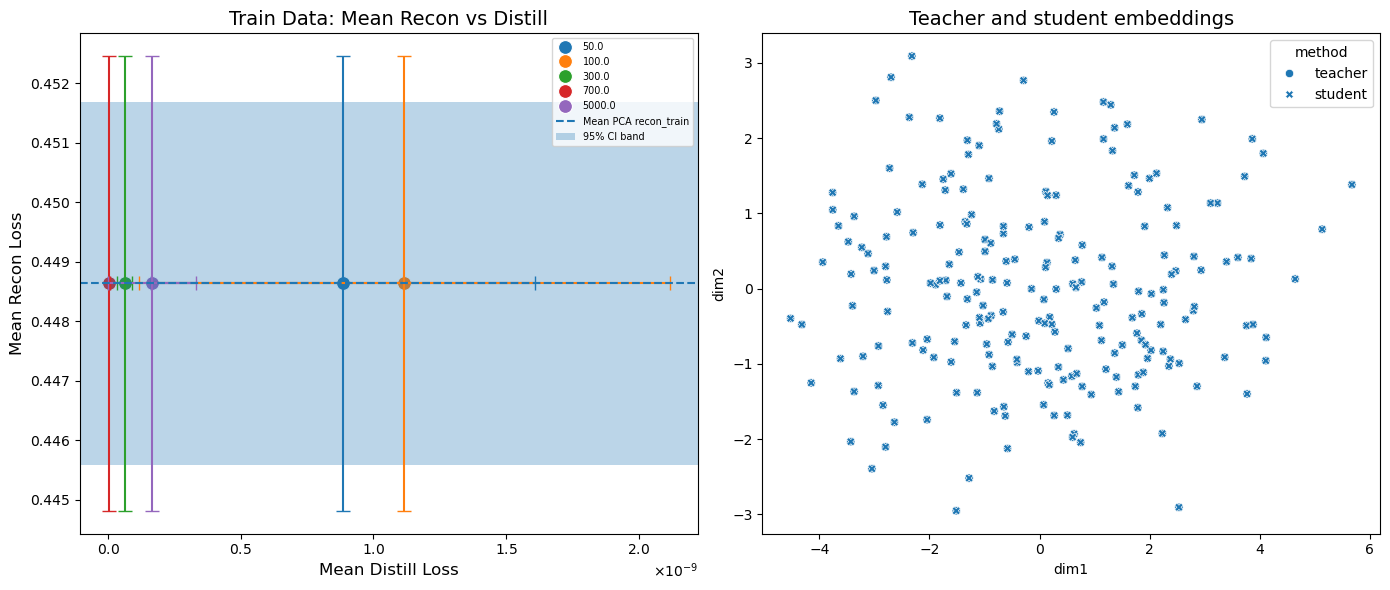

In [75]:
df_single_cell = pd.read_csv(lambda_exp_file)
df_single_cell = df_single_cell[df_single_cell.student_method == "drd"]
# Prepare the figure with two subplots: train and test
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

# Compute mean and SEM across seeds for each lambda_d
plot_lambda_recon_distill_train(df_single_cell, axes[0])
sns.scatterplot(df, x = 'dim1', y= 'dim2', palette='tab10', ax=axes[1], style='method')
axes[1].set_title(f'Teacher and student embeddings', fontsize=14)
plt.tight_layout()
plt.show()


In [3]:
# Prefix used in your table
prefix = 'config/teacher_config/'
teacher_col = prefix + 'teacher'

def _fmt(v):
    if pd.isna(v): 
        return None
    if isinstance(v, (int, np.integer)): 
        return str(v)
    if isinstance(v, float):
        return f"{v:.4g}" if not float(v).is_integer() else str(int(v))
    return str(v)

def make_label(row, param_cols):
    teacher = str(row[teacher_col])
    # include only params that are present on this row
    parts = []
    for c in sorted(param_cols):  # sorted for consistent ordering
        v = _fmt(row[c])
        if v is not None:
            key = c.split('/')[-1]  # e.g. "t_n_neighbors", "min_dist", ...
            parts.append(f"{key}={v}")
    return f"{teacher}({', '.join(parts)})" if parts else teacher


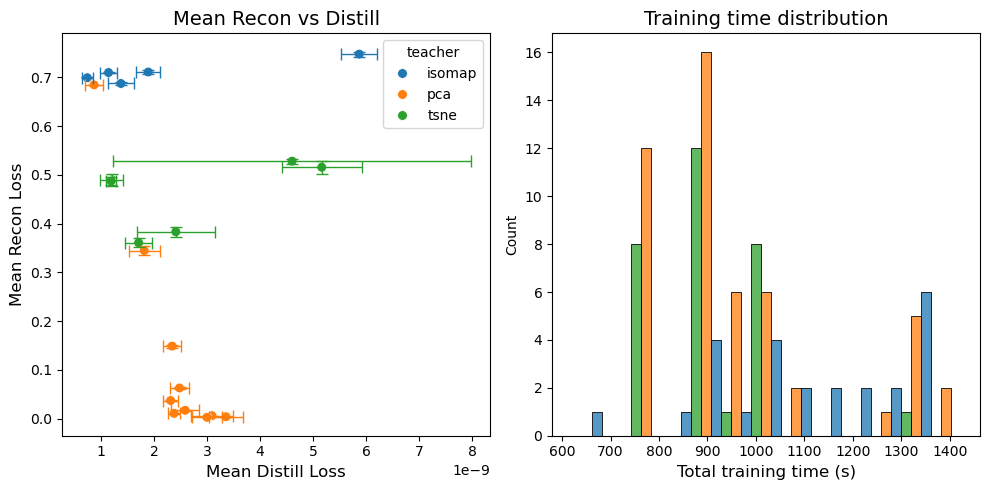

In [45]:
df_pancan_tsne = pd.read_csv('/shared/share_mala/irchang/drd/distill_loss/gene_cancer_tsne.csv')
df_pancan_pca = pd.read_csv('/shared/share_mala/irchang/drd/distill_loss/gene_cancer_pca.csv')
df_pancan_isomap = pd.read_csv('/shared/share_mala/irchang/drd/distill_loss/gene_cancer_isomap.csv')
df_pancan_umap = pd.read_csv('/shared/share_mala/irchang/drd/distill_loss/gene_cancer_umap.csv')
df_pancan = pd.concat([df_pancan_tsne, df_pancan_pca, df_pancan_isomap], ignore_index=True)
param_cols = [c for c in df_pancan.columns if c.startswith(prefix) and c != teacher_col]
df_pancan['teacher_cfg'] = df_pancan.apply(make_label, param_cols = param_cols, axis=1)
# Compute mean and SEM across seeds for each lambda_d
grouped = df_pancan.groupby(['config/teacher_config/teacher', 'teacher_cfg']).agg(
    mean_distill=('distill_loss', 'mean'),
    sem_distill=(f'distill_loss', 'sem'),
    mean_recon=('recon_loss', 'mean'),
    sem_recon=('recon_loss', 'sem')
).reset_index()

# Unique teachers and a proper mapping: teacher -> single color
teachers = grouped['config/teacher_config/teacher'].unique()
colors   = sns.color_palette("tab10", n_colors=len(teachers))
palette  = dict(zip(teachers, colors)) 

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=False, sharey=False)
ax0 = axes[0]

# --- Scatter all points in one call (Seaborn handles colors by hue) ---
sns.scatterplot(
    data=grouped,
    x='mean_distill', y='mean_recon',
    hue='config/teacher_config/teacher',
    palette=palette, s=50, ax=ax0, legend=True
)
ax0.legend(title='teacher')

# --- Add error bars with matching color per teacher ---
for _, row in grouped.iterrows():
    t = row['config/teacher_config/teacher']
    col = palette[t]
    ax0.errorbar(
        row['mean_distill'], row['mean_recon'],
        xerr=row['sem_distill'], yerr=row['sem_recon'],
        fmt='none', ecolor=col, elinewidth=1, capsize=4
    )

# Formatting
ax0.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax0.set_xlabel('Mean Distill Loss', fontsize=12)
ax0.set_ylabel('Mean Recon Loss', fontsize=12)
ax0.set_title('Mean Recon vs Distill', fontsize=14)

# --- Your second plot (train curves) ---
sns.histplot(
    data=df_pancan, x='time_total_s',
    hue='config/teacher_config/teacher', multiple='dodge',
    palette=palette, legend=False, ax=axes[1]
)
axes[1].set_title('Training time distribution', fontsize=14)
axes[1].set_xlabel('Total training time (s)', fontsize=12)

plt.tight_layout()
plt.show()


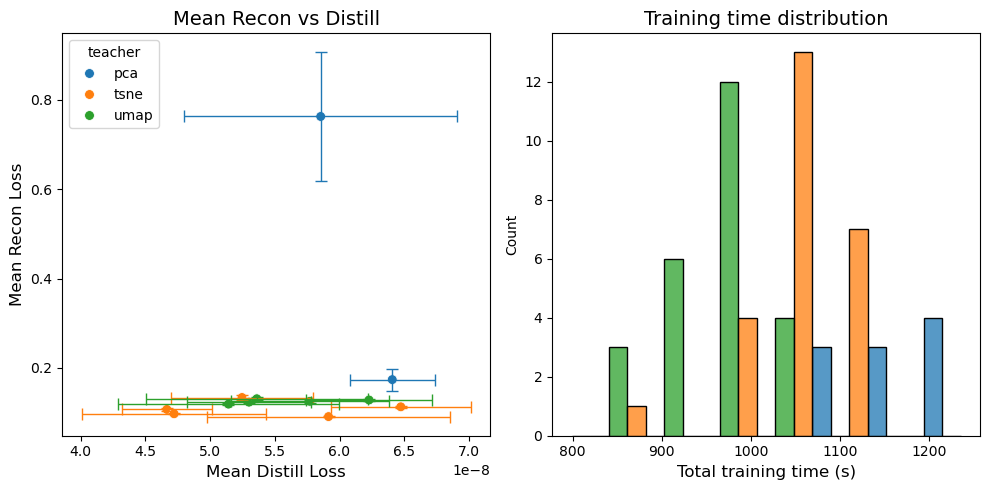

In [47]:
df_wine_tsne = pd.read_csv('/shared/share_mala/irchang/drd/distill_loss/wine_tsne.csv')
df_wine_tsne = df_wine_tsne[df_wine_tsne['config/teacher_config/perplexity'] < 176]
df_wine_pca = pd.read_csv('/shared/share_mala/irchang/drd/distill_loss/wine_pca.csv')
df_wine_pca = df_wine_pca[df_wine_pca['config/teacher_config/n_components'] <= 4]
# df_wine_isomap = pd.read_csv('/shared/share_mala/irchang/drd/distill_loss/gene_cancer_isomap.csv')
df_wine_umap = pd.read_csv('/shared/share_mala/irchang/drd/distill_loss/wine_umap.csv')
df_pancan = pd.concat([df_wine_tsne, df_wine_pca, df_wine_umap], ignore_index=True)
param_cols = [c for c in df_pancan.columns if c.startswith(prefix) and c != teacher_col]
df_pancan['teacher_cfg'] = df_pancan.apply(make_label, param_cols = param_cols, axis=1)
# Compute mean and SEM across seeds for each lambda_d
grouped = df_pancan.groupby(['config/teacher_config/teacher', 'teacher_cfg']).agg(
    mean_distill=('distill_loss', 'mean'),
    sem_distill=(f'distill_loss', 'sem'),
    mean_recon=('recon_loss', 'mean'),
    sem_recon=('recon_loss', 'sem')
).reset_index()

# Unique teachers and a proper mapping: teacher -> single color
teachers = grouped['config/teacher_config/teacher'].unique()
colors   = sns.color_palette("tab10", n_colors=len(teachers))
palette  = dict(zip(teachers, colors)) 

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=False, sharey=False)
ax0 = axes[0]

# --- Scatter all points in one call (Seaborn handles colors by hue) ---
sns.scatterplot(
    data=grouped,
    x='mean_distill', y='mean_recon',
    hue='config/teacher_config/teacher',
    palette=palette, s=50, ax=ax0, legend=True
)
ax0.legend(title='teacher')

# --- Add error bars with matching color per teacher ---
for _, row in grouped.iterrows():
    t = row['config/teacher_config/teacher']
    col = palette[t]
    ax0.errorbar(
        row['mean_distill'], row['mean_recon'],
        xerr=row['sem_distill'], yerr=row['sem_recon'],
        fmt='none', ecolor=col, elinewidth=1, capsize=4
    )

# Formatting
ax0.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax0.set_xlabel('Mean Distill Loss', fontsize=12)
ax0.set_ylabel('Mean Recon Loss', fontsize=12)
ax0.set_title('Mean Recon vs Distill', fontsize=14)

# --- Your second plot (train curves) ---
sns.histplot(
    data=df_pancan, x='time_total_s',
    hue='config/teacher_config/teacher', multiple='dodge',
    palette=palette, legend=False, ax=axes[1]
)
axes[1].set_title('Training time distribution', fontsize=14)
axes[1].set_xlabel('Total training time (s)', fontsize=12)

plt.tight_layout()
plt.show()


# Jul 7

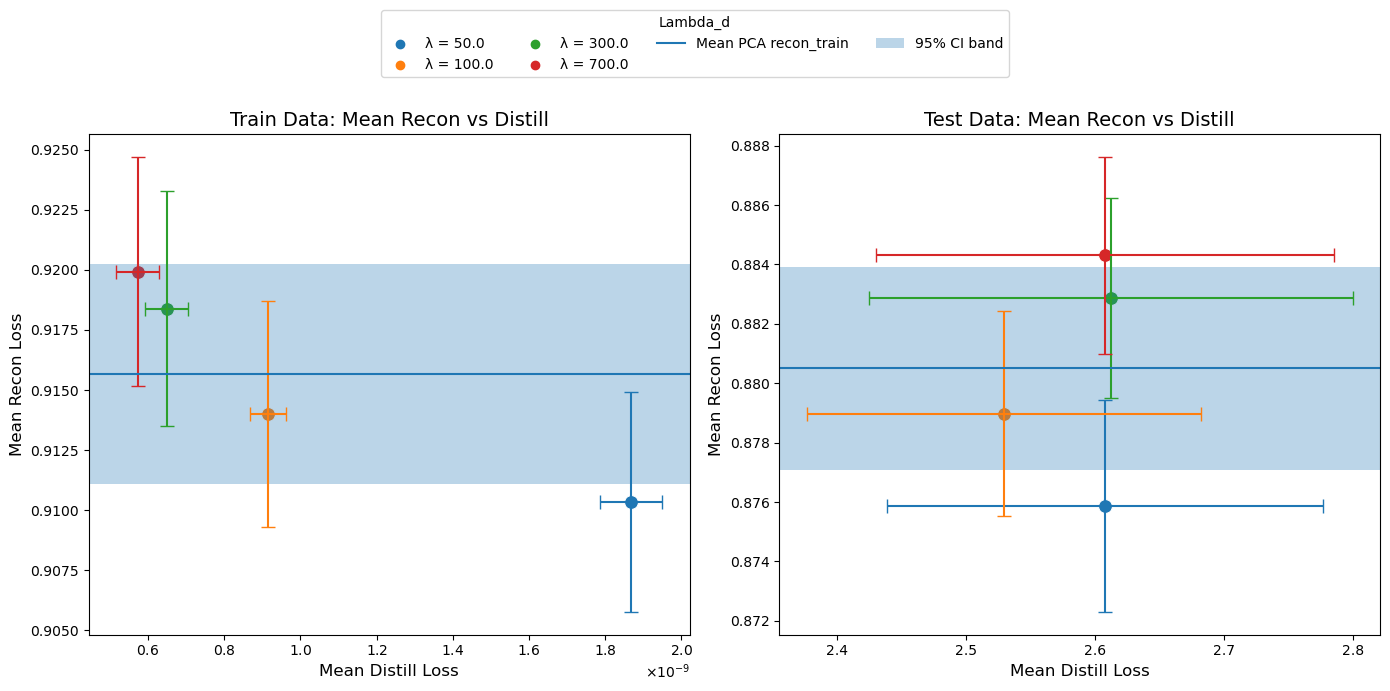

In [ ]:
df_single_cell = pd.read_csv('results/single_cell_pca_drd_joint_n=801_v3.csv')
df_single_cell = df_single_cell[df_single_cell.student_method == "drd"]
# Prepare the figure with two subplots: train and test
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

for idx, split in enumerate(['train', 'test']):
    ax = axes[idx]
    
    # Compute mean and SEM across seeds for each lambda_d
    grouped = df_single_cell.groupby('lambda_d').agg(
        mean_distill=('distill_' + split, 'mean'),
        sem_distill=(f'distill_{split}', 'sem'),
        mean_recon=('recon_' + split, 'mean'),
        sem_recon=('recon_' + split, 'sem')
    ).reset_index()
    
    # Create a color palette
    palette = sns.color_palette("tab10", n_colors=len(grouped))
    
    # Plot each point with error bars
    for i, row in grouped.iterrows():
        sns.scatterplot(x=[row['mean_distill']], y=[row['mean_recon']],hue=[row['lambda_d']],
            palette=[palette[i]], legend=False, s=100,ax=ax)
        ax.errorbar(row['mean_distill'], row['mean_recon'],yerr=row['sem_recon'], 
                    xerr=row['sem_distill'], fmt='none', ecolor=palette[i], capsize=5)
    
    if split == "train": 
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    # Set labels and title
    ax.set_xlabel('Mean Distill Loss', fontsize=12)
    ax.set_ylabel('Mean Recon Loss', fontsize=12)
    ax.set_title(f'{split.title()} Data: Mean Recon vs Distill', fontsize=14)
    
    # Create a custom legend
    for i, lam in enumerate(grouped['lambda_d']):
        ax.scatter([], [], color=palette[i], label=f'λ = {lam}')
    plot_pca_recon(df_single_cell, ax, split)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Lambda_d', ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.02),)
plt.tight_layout()
plt.show()


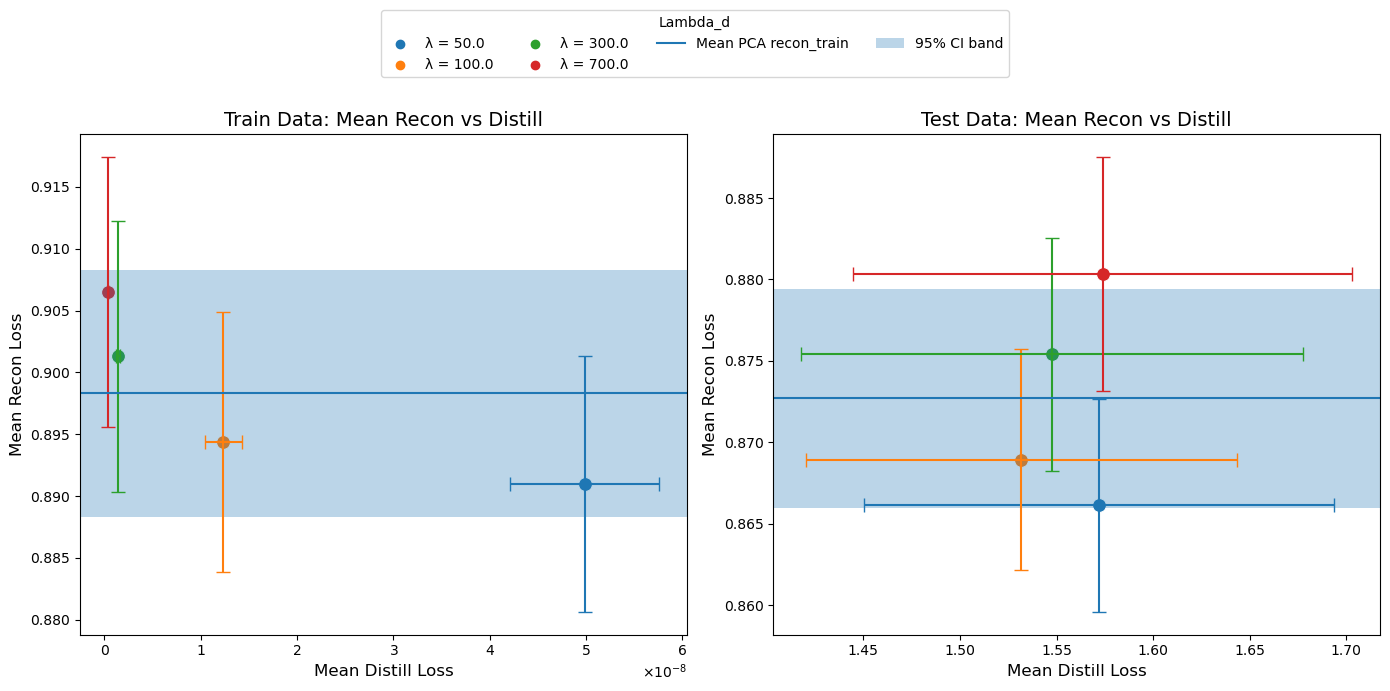

In [17]:
df_single_cell = pd.read_csv('results/single_cell_umap_drd_joint_n=801.csv')
df_single_cell = df_single_cell[df_single_cell.student_method == "drd"]
# Prepare the figure with two subplots: train and test
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

for idx, split in enumerate(['train', 'test']):
    ax = axes[idx]
    
    # Compute mean and SEM across seeds for each lambda_d
    grouped = df_single_cell.groupby('lambda_d').agg(
        mean_distill=('distill_' + split, 'mean'),
        sem_distill=(f'distill_{split}', 'sem'),
        mean_recon=('recon_' + split, 'mean'),
        sem_recon=('recon_' + split, 'sem')
    ).reset_index()
    
    # Create a color palette
    palette = sns.color_palette("tab10", n_colors=len(grouped))
    
    # Plot each point with error bars
    for i, row in grouped.iterrows():
        sns.scatterplot(x=[row['mean_distill']], y=[row['mean_recon']],hue=[row['lambda_d']],
            palette=[palette[i]], legend=False, s=100,ax=ax)
        ax.errorbar(row['mean_distill'], row['mean_recon'],yerr=row['sem_recon'], 
                    xerr=row['sem_distill'], fmt='none', ecolor=palette[i], capsize=5)
    
    if split == "train": 
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    # Set labels and title
    ax.set_xlabel('Mean Distill Loss', fontsize=12)
    ax.set_ylabel('Mean Recon Loss', fontsize=12)
    ax.set_title(f'{split.title()} Data: Mean Recon vs Distill', fontsize=14)
    
    # Create a custom legend
    for i, lam in enumerate(grouped['lambda_d']):
        ax.scatter([], [], color=palette[i], label=f'λ = {lam}')
    plot_pca_recon(df_single_cell, ax, split)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Lambda_d', ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.02),)
plt.tight_layout()
plt.show()


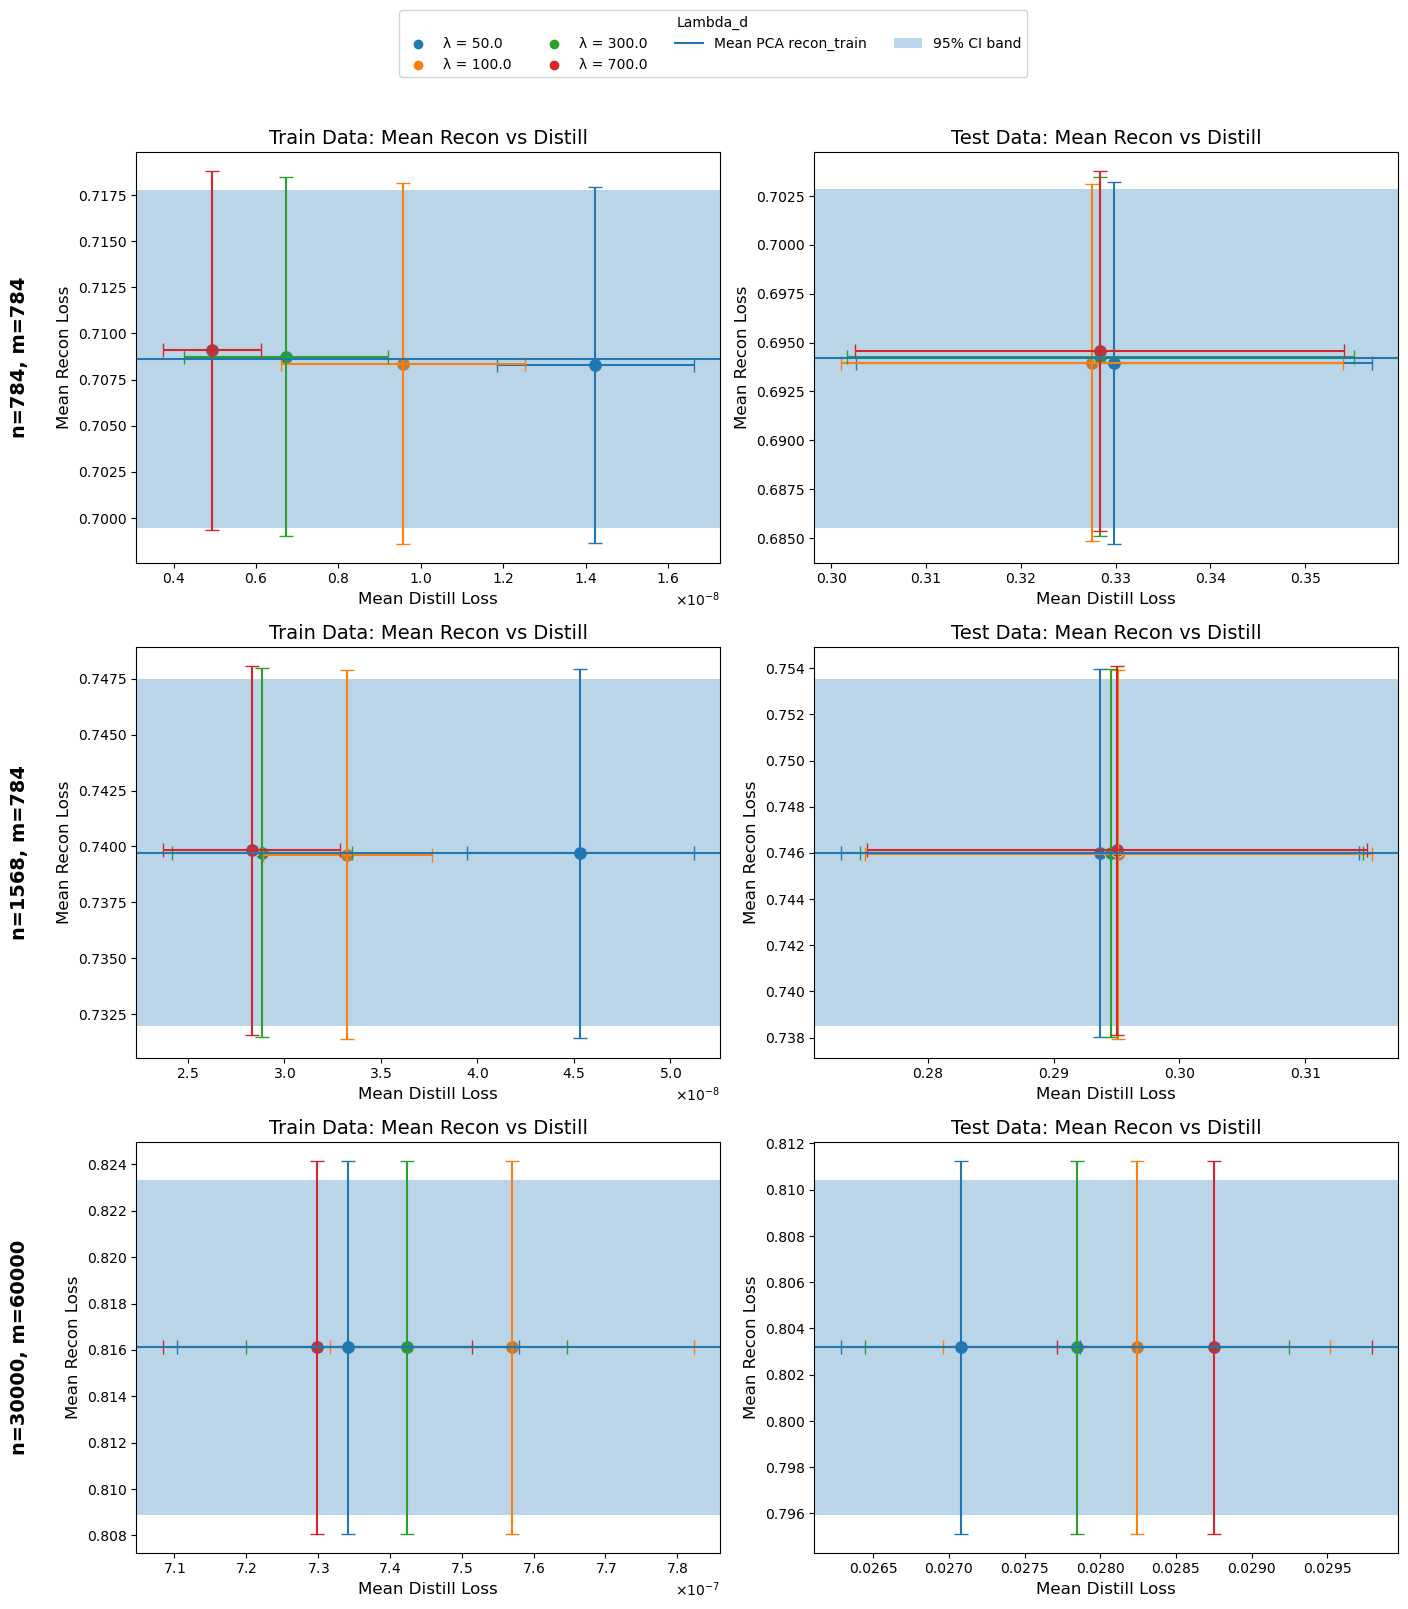

In [35]:
df_mnist_784 = pd.read_csv('results/mnist_pca_drd_joint_n=784.csv')
df_mnist_784 = df_mnist_784[df_mnist_784.student_method == "drd"]

df_mnist_1568 = pd.read_csv('results/mnist_pca_drd_joint_n=1568.csv')
df_mnist_1568 = df_mnist_1568[df_mnist_1568.student_method == "drd"]

df_mnist_30000 = pd.read_csv('results/mnist_pca_drd_joint_n=30000.csv')
df_mnist_30000 = df_mnist_30000[df_mnist_30000.student_method == "drd"]
# Prepare the figure with two subplots: train and test
fig, axes_big = plt.subplots(3, 2, figsize=(14, 15), sharex=False, sharey=False)
list_df_labels = ['n=784, m=784', 'n=1568, m=784', 'n=30000, m=60000']
list_df = [df_mnist_784, df_mnist_1568, df_mnist_30000]
for num_idx, num in enumerate(list_df_labels):
    df = list_df[num_idx]
    axes = axes_big[num_idx]
    for idx, split in enumerate(['train', 'test']):
        ax = axes[idx]
        
        # Compute mean and SEM across seeds for each lambda_d
        grouped = df.groupby('lambda_d').agg(
            mean_distill=('distill_' + split, 'mean'),
            sem_distill=(f'distill_{split}', 'sem'),
            mean_recon=('recon_' + split, 'mean'),
            sem_recon=('recon_' + split, 'sem')
        ).reset_index()
        
        # Create a color palette
        palette = sns.color_palette("tab10", n_colors=len(grouped))
        
        # Plot each point with error bars
        for i, row in grouped.iterrows():
            sns.scatterplot(x=[row['mean_distill']], y=[row['mean_recon']],hue=[row['lambda_d']],
                palette=[palette[i]], legend=False, s=100,ax=ax)
            ax.errorbar(row['mean_distill'], row['mean_recon'],yerr=row['sem_recon'], 
                        xerr=row['sem_distill'], fmt='none', ecolor=palette[i], capsize=5)
        
        if split == "train": 
            ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
            ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        # Set labels and title
        ax.set_xlabel('Mean Distill Loss', fontsize=12)
        ax.set_ylabel('Mean Recon Loss', fontsize=12)
        ax.set_title(f'{split.title()} Data: Mean Recon vs Distill', fontsize=14)
        
        # Create a custom legend
        for i, lam in enumerate(grouped['lambda_d']):
            ax.scatter([], [], color=palette[i], label=f'λ = {lam}')
        plot_pca_recon(df, ax, split)
        if idx == 0:
            ax.annotate(
                f'{num}',
                xy=(-0.2, 0.5),      # x,y in *axes* coords: x<0 is left margin
                xycoords='axes fraction',
                va='center', ha='center',
                fontsize=14, fontweight='bold',
                rotation='vertical'
            )

handles, labels = axes_big[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Lambda_d', ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.02),)
plt.tight_layout()
plt.show()

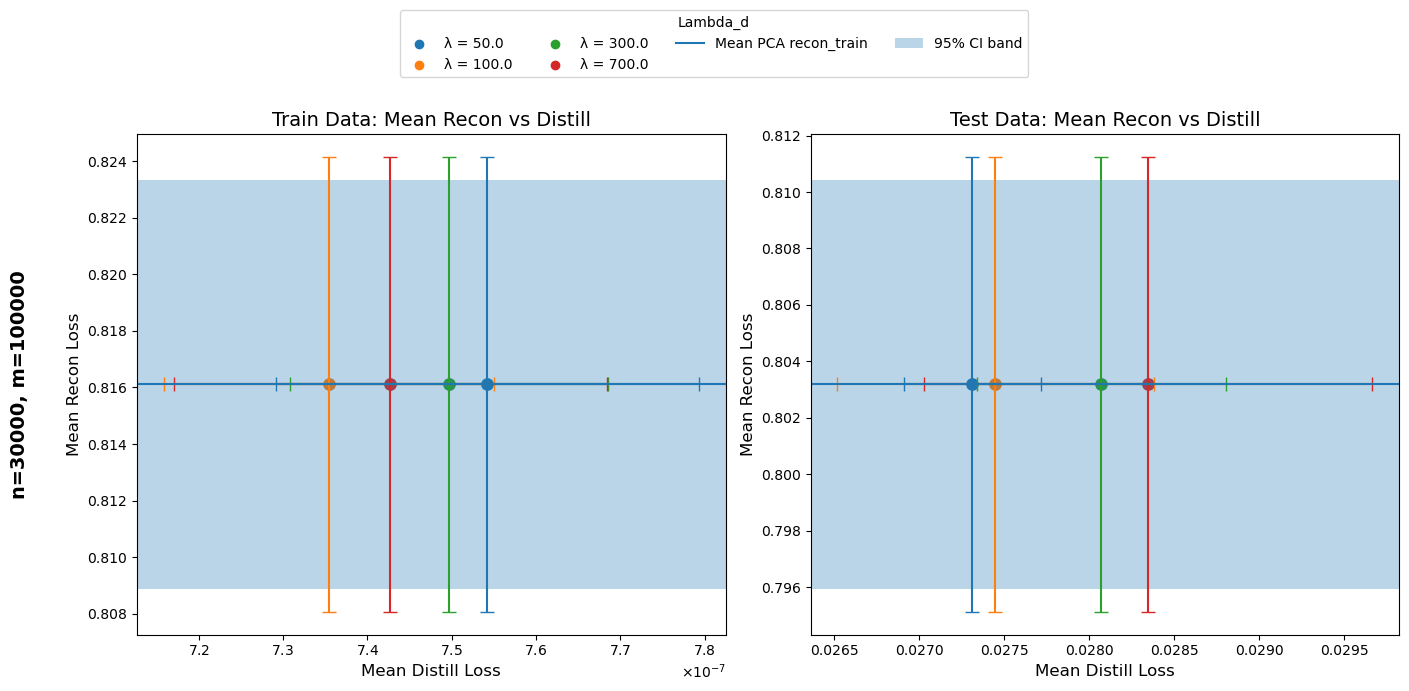

In [41]:
df_mnist = pd.read_csv('results/mnist_umap_drd_joint_n=30000.csv')
df_mnist = df_mnist[df_mnist.student_method == "drd"]
# Prepare the figure with two subplots: train and test
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

for idx, split in enumerate(['train', 'test']):
    ax = axes[idx]
    
    # Compute mean and SEM across seeds for each lambda_d
    grouped = df_mnist.groupby('lambda_d').agg(
        mean_distill=('distill_' + split, 'mean'),
        sem_distill=(f'distill_{split}', 'sem'),
        mean_recon=('recon_' + split, 'mean'),
        sem_recon=('recon_' + split, 'sem')
    ).reset_index()
    
    # Create a color palette
    palette = sns.color_palette("tab10", n_colors=len(grouped))
    
    # Plot each point with error bars
    for i, row in grouped.iterrows():
        sns.scatterplot(x=[row['mean_distill']], y=[row['mean_recon']],hue=[row['lambda_d']],
            palette=[palette[i]], legend=False, s=100,ax=ax)
        ax.errorbar(row['mean_distill'], row['mean_recon'],yerr=row['sem_recon'], 
                    xerr=row['sem_distill'], fmt='none', ecolor=palette[i], capsize=5)
    
    if split == "train": 
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    # Set labels and title
    ax.set_xlabel('Mean Distill Loss', fontsize=12)
    ax.set_ylabel('Mean Recon Loss', fontsize=12)
    ax.set_title(f'{split.title()} Data: Mean Recon vs Distill', fontsize=14)
    
    # Create a custom legend
    for i, lam in enumerate(grouped['lambda_d']):
        ax.scatter([], [], color=palette[i], label=f'λ = {lam}')
    plot_pca_recon(df_mnist, ax, split)
    if idx == 0:
        ax.annotate(
            'n=30000, m=100000',
            xy=(-0.2, 0.5),      # x,y in *axes* coords: x<0 is left margin
            xycoords='axes fraction',
            va='center', ha='center',
            fontsize=14, fontweight='bold',
            rotation='vertical'
        )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Lambda_d', ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.02),)
plt.tight_layout()
plt.show()


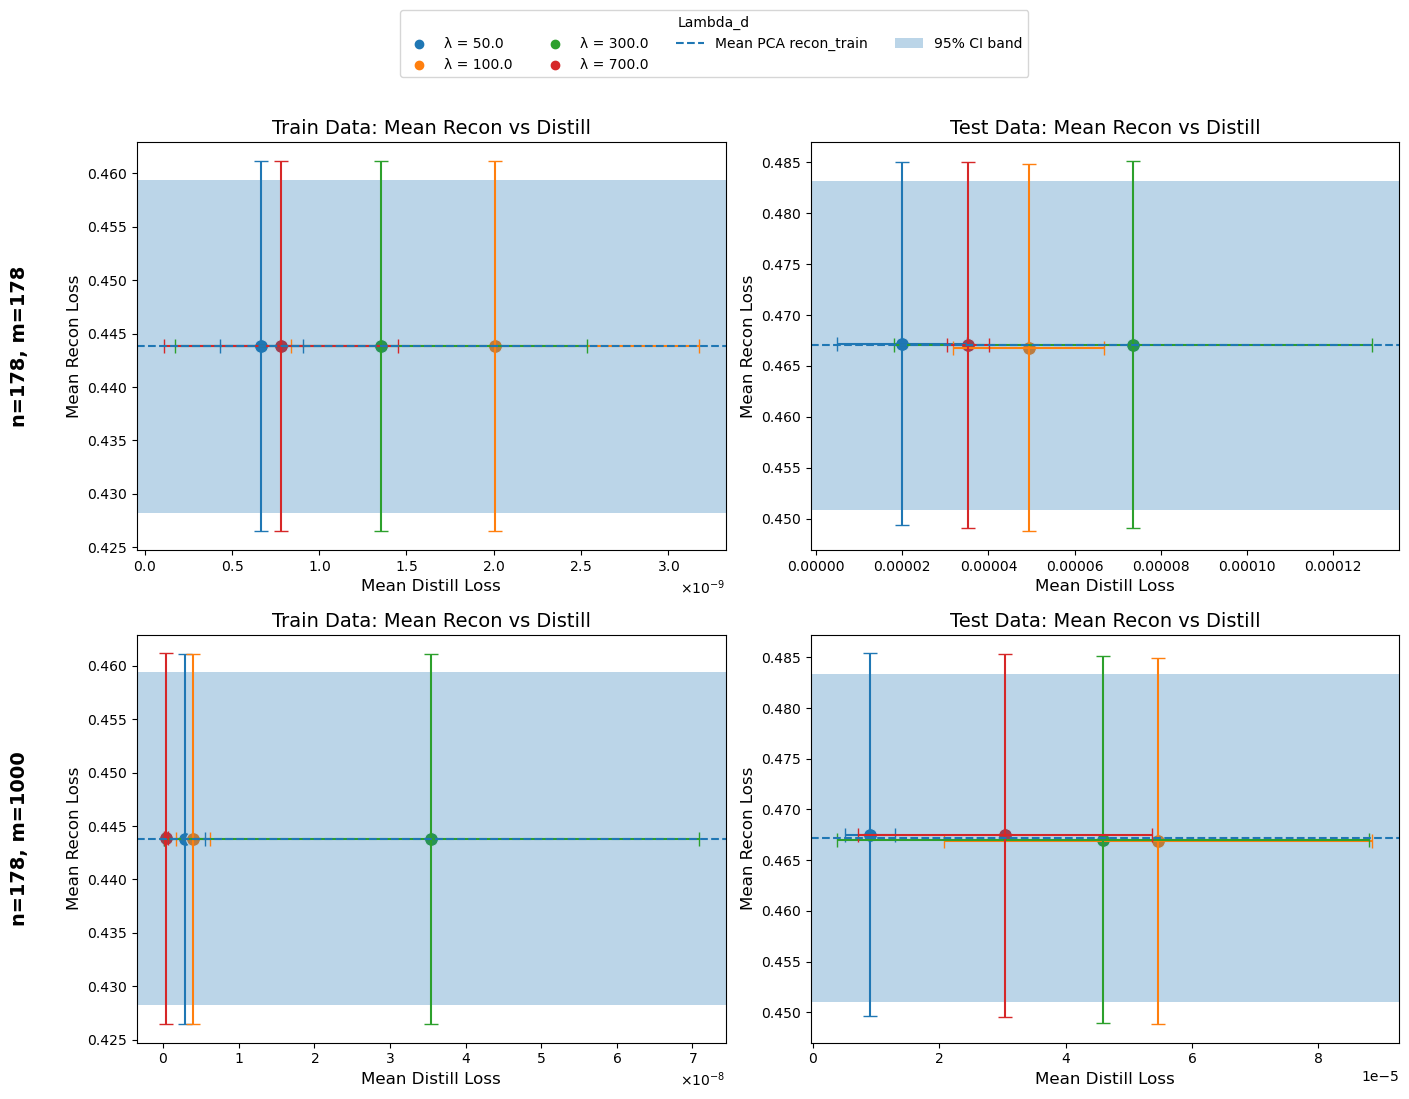

In [49]:
df_wine_178 = pd.read_csv('results/wine_pca_drd_joint_n=178.csv')
df_wine_178 = df_wine_178[df_wine_178.student_method == "drd"]

df_wine_1000 = pd.read_csv('results/wine_pca_drd_joint_n=178_v2.csv')
df_wine_1000 = df_wine_1000[df_wine_1000.student_method == "drd"]
# Prepare the figure with two subplots: train and test
fig, axes_big = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
list_df_labels = ['n=178, m=178', 'n=178, m=1000']
list_df = [df_wine_178, df_wine_1000]
for num_idx, num in enumerate(list_df_labels):
    df = list_df[num_idx]
    axes = axes_big[num_idx]
    for idx, split in enumerate(['train', 'test']):
        ax = axes[idx]
        
        # Compute mean and SEM across seeds for each lambda_d
        grouped = df.groupby('lambda_d').agg(
            mean_distill=('distill_' + split, 'mean'),
            sem_distill=(f'distill_{split}', 'sem'),
            mean_recon=('recon_' + split, 'mean'),
            sem_recon=('recon_' + split, 'sem')
        ).reset_index()
        
        # Create a color palette
        palette = sns.color_palette("tab10", n_colors=len(grouped))
        
        # Plot each point with error bars
        for i, row in grouped.iterrows():
            sns.scatterplot(x=[row['mean_distill']], y=[row['mean_recon']],hue=[row['lambda_d']],
                palette=[palette[i]], legend=False, s=100,ax=ax)
            ax.errorbar(row['mean_distill'], row['mean_recon'],yerr=row['sem_recon'], 
                        xerr=row['sem_distill'], fmt='none', ecolor=palette[i], capsize=5)
        
        if split == "train": 
            ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
            ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        # Set labels and title
        ax.set_xlabel('Mean Distill Loss', fontsize=12)
        ax.set_ylabel('Mean Recon Loss', fontsize=12)
        ax.set_title(f'{split.title()} Data: Mean Recon vs Distill', fontsize=14)
        
        # Create a custom legend
        for i, lam in enumerate(grouped['lambda_d']):
            ax.scatter([], [], color=palette[i], label=f'λ = {lam}')
        plot_pca_recon(df, ax, split)
        if idx == 0:
            ax.annotate(
                f'{num}',
                xy=(-0.2, 0.5),      # x,y in *axes* coords: x<0 is left margin
                xycoords='axes fraction',
                va='center', ha='center',
                fontsize=14, fontweight='bold',
                rotation='vertical'
            )

handles, labels = axes_big[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Lambda_d', ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.02),)
plt.tight_layout()
plt.show()

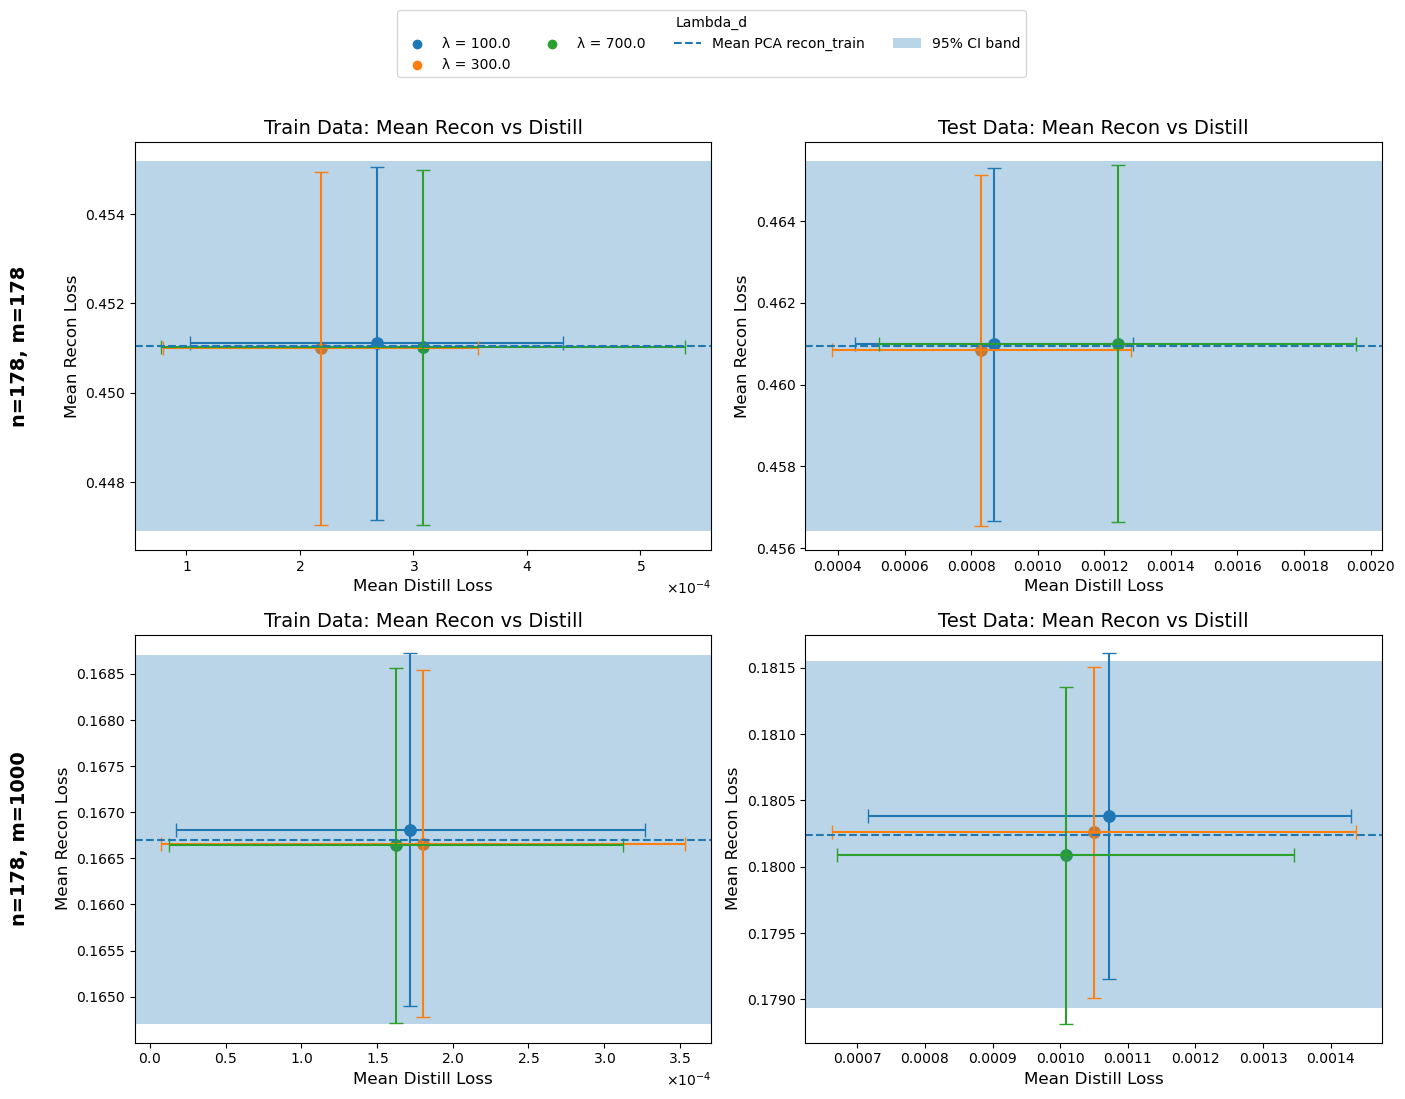

In [50]:
df_wine_178 = pd.read_csv('results/diabetes_pca_drd_joint_n=442_lat=2.csv')
df_wine_178 = df_wine_178[df_wine_178.student_method == "drd"]

df_wine_1000 = pd.read_csv('results/diabetes_pca_drd_joint_n=442_lat=5.csv')
df_wine_1000 = df_wine_1000[df_wine_1000.student_method == "drd"]
# Prepare the figure with two subplots: train and test
fig, axes_big = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
list_df_labels = ['n=178, m=178', 'n=178, m=1000']
list_df = [df_wine_178, df_wine_1000]
for num_idx, num in enumerate(list_df_labels):
    df = list_df[num_idx]
    axes = axes_big[num_idx]
    for idx, split in enumerate(['train', 'test']):
        ax = axes[idx]
        
        # Compute mean and SEM across seeds for each lambda_d
        grouped = df.groupby('lambda_d').agg(
            mean_distill=('distill_' + split, 'mean'),
            sem_distill=(f'distill_{split}', 'sem'),
            mean_recon=('recon_' + split, 'mean'),
            sem_recon=('recon_' + split, 'sem')
        ).reset_index()
        
        # Create a color palette
        palette = sns.color_palette("tab10", n_colors=len(grouped))
        
        # Plot each point with error bars
        for i, row in grouped.iterrows():
            sns.scatterplot(x=[row['mean_distill']], y=[row['mean_recon']],hue=[row['lambda_d']],
                palette=[palette[i]], legend=False, s=100,ax=ax)
            ax.errorbar(row['mean_distill'], row['mean_recon'],yerr=row['sem_recon'], 
                        xerr=row['sem_distill'], fmt='none', ecolor=palette[i], capsize=5)
        
        if split == "train": 
            ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
            ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        # Set labels and title
        ax.set_xlabel('Mean Distill Loss', fontsize=12)
        ax.set_ylabel('Mean Recon Loss', fontsize=12)
        ax.set_title(f'{split.title()} Data: Mean Recon vs Distill', fontsize=14)
        
        # Create a custom legend
        for i, lam in enumerate(grouped['lambda_d']):
            ax.scatter([], [], color=palette[i], label=f'λ = {lam}')
        plot_pca_recon(df, ax, split)
        if idx == 0:
            ax.annotate(
                f'{num}',
                xy=(-0.2, 0.5),      # x,y in *axes* coords: x<0 is left margin
                xycoords='axes fraction',
                va='center', ha='center',
                fontsize=14, fontweight='bold',
                rotation='vertical'
            )

handles, labels = axes_big[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Lambda_d', ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.02),)
plt.tight_layout()
plt.show()